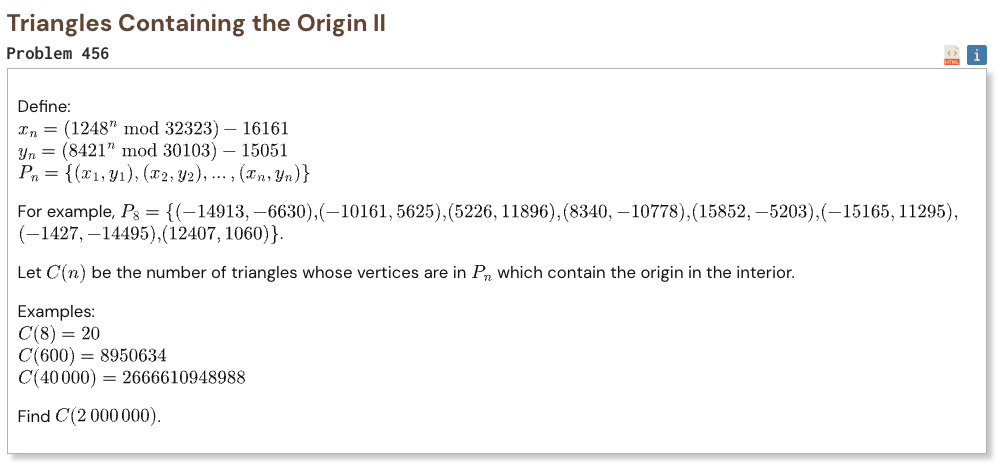

## Initial approach

-   generate all points using the two modular recurrence relations
-   reduce every point to its direction from the origin using gcd
-   sort the directions by angle around the origin
-   combine points that lie on exactly the same ray because they cannot form a valid containing triangle together
-   count all triples that use three different directions
-   use a two pointer window to find directions lying within a half circle
-   every triangle inside a half circle does not contain the origin, so subtract these from the total
-   include exactly opposite directions in the half circle boundary because those triangles only touch the origin

In [1]:
%%time

import math
from math import gcd

N = 2_000_000

x = 1
y = 1
points = []

for _ in range(N):
    x = x * 1248 % 32323
    y = y * 8421 % 30103

    px = x - 16161
    py = y - 15051

    g = gcd(abs(px), abs(py))
    dx = px // g
    dy = py // g

    points.append((math.atan2(dy, dx), dx, dy))

points.sort()

directions = []
counts = []

last = None

for _, dx, dy in points:
    direction = (dx, dy)

    if direction == last:
        counts[-1] += 1
    else:
        directions.append(direction)
        counts.append(1)
        last = direction

size = len(directions)

total = 0
count_sum = 0
square_sum = 0

for count in counts:
    total += count * (count_sum * count_sum - square_sum) // 2
    count_sum += count
    square_sum += count * count

prefix = [0] * (size + 1)
prefix_square = [0] * (size + 1)

for i, count in enumerate(counts):
    prefix[i + 1] = prefix[i] + count
    prefix_square[i + 1] = prefix_square[i] + count * count

def range_sum(prefix_array, left, right):
    if right <= size:
        return prefix_array[right] - prefix_array[left]

    return (
        prefix_array[size]
        - prefix_array[left]
        + prefix_array[right - size]
    )

bad = 0
j = 1

for i in range(size):
    if j < i + 1:
        j = i + 1

    ax, ay = directions[i]

    while j < i + size:
        bx, by = directions[j % size]

        cross = ax * by - ay * bx
        dot = ax * bx + ay * by

        if cross > 0 or (cross == 0 and dot < 0):
            j += 1
        else:
            break

    count_sum = range_sum(prefix, i + 1, j)
    square_sum = range_sum(prefix_square, i + 1, j)

    pair_count = (
        count_sum * count_sum - square_sum
    ) // 2

    bad += counts[i] * pair_count

result = total - bad

print("Result:", result)

Result: 333333208685971546
CPU times: user 5.2 s, sys: 98 ms, total: 5.3 s
Wall time: 5.3 s
